In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('../graphs/results.csv')
df.head(10)

,Task,Method,Sampler,Model,Batch,Seed,Size,r2,mae,rmse,rmse-rel,pearson,spearman
0,freesolv,random,none,none,none,5,100,0.78264,0.30556,0.46622,0.46622,0.88517,0.87736
1,freesolv,random,none,none,none,7,100,0.70593,0.33244,0.54228,0.54228,0.84878,0.88753
2,polygas_He,random,none,none,none,6,100,0.70624,0.35177,0.54200,0.54200,0.85199,0.84653
3,polygas_CO2,random,none,none,none,1,100,0.76896,0.32278,0.48067,0.48067,0.87796,0.89374
4,polygas_H2,random,none,none,none,1,100,0.77995,0.29809,0.46910,0.46910,0.88492,0.89537
5,polygas_CO2,random,none,none,none,6,100,0.66622,0.37255,0.57774,0.57774,0.83035,0.83315
6,polygas_O2,random,none,none,none,7,100,0.63753,0.37380,0.60205,0.60205,0.80572,0.81097
7,sublimation,random,none,none,none,7,100,0.68427,0.37937,0.56190,0.56190,0.82922,0.84336
8,esol,random,none,none,none,7,100,0.80054,0.32280,0.44661,0.44661,0.89779,0.88527
9,esol,random,none,none,none,9,100,0.75375,0.35513,0.49624,0.49624,0.87717,0.87027


In [3]:
df['Method'].unique()

array(['random', 'penultimate', 'embedding', 'ensemble', 'hallucinate',
       'top', 'pareto'], dtype=object)

In [4]:
METRIC = 'spearman'
task_results = df[['Task', 'Method', 'Seed', 'Size', METRIC]]

task_results_long = task_results.melt(
    id_vars=['Task', 'Method', 'Seed'],
    value_vars=['spearman'],
    var_name='metric_full',
    value_name='metric_value'
)
task_results_long.head(10)
task_performances = task_results_long.loc[:,['Task', 'Method', 'Seed', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)

print(task_performances.head(30))

task_performances = task_performances[(task_performances['mean'] > 0.1)]
intermediate_tasks = task_performances['Task'].to_list()
print(f'Number of tasks: {len(intermediate_tasks)}')

               Task      mean
28         qm9_zpve  0.900536
3          freesolv  0.837605
23         qm9_lumo  0.833974
16       polymer_tg  0.829335
10       polygas_He  0.827409
20          qm9_gap  0.826656
8       polygas_CO2  0.826502
9        polygas_H2  0.823303
2              esol  0.820814
12       polygas_O2  0.819529
11       polygas_N2  0.819207
7       polygas_CH4  0.818775
18           qm9_cv  0.799607
29      sublimation  0.795323
1         chain_gap  0.789340
6    pcqm4mv2_small  0.724288
13  polymer_density  0.723651
21         qm9_h298  0.720423
27         qm9_u298  0.719400
19         qm9_g298  0.719031
26           qm9_u0  0.718161
17        qm9_alpha  0.698160
25           qm9_r2  0.651459
5              logp  0.637184
14       polymer_mt  0.631874
0              bace  0.604920
22         qm9_homo  0.579436
24           qm9_mu  0.460035
4              lipo  0.385212
15       polymer_o2  0.270204
Number of tasks: 30


In [5]:
METRIC = 'spearman'
intermediate_results = df[['Task', 'Method', 'Seed', 'Size', METRIC]]
intermediate_results_long = intermediate_results.melt(
    id_vars=['Task', 'Method', 'Seed'],
    value_vars=[METRIC],
    var_name='metric_full',
    value_name='metric_value'
)
intermediate_results_long.head(10)
intermediate_results_long = intermediate_results_long[intermediate_results_long['Task'].isin(intermediate_tasks)]

norm_factors = intermediate_results_long.groupby(['Task', 'Method'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
intermediate_results_long['score_norm'] = intermediate_results_long['metric_value'] / intermediate_results_long['Task'].map(norm_factors)
intermediate_results_long = intermediate_results_long[['Method', 'score_norm']]

intermediate_results_grouped = intermediate_results_long.groupby(['Method'])
intermediate_results_agg = intermediate_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    intermediate_results_agg = intermediate_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rmse-rel']:
    intermediate_results_agg = intermediate_results_agg.sort_values(by='mean', ascending=True)
intermediate_results_agg.head(50)

,Method,mean,sem
1,ensemble,0.973858,0.003154
0,embedding,0.973449,0.003213
4,penultimate,0.969501,0.003366
5,random,0.960566,0.004506
2,hallucinate,0.951684,0.005882
3,pareto,0.944503,0.006046
6,top,0.610605,0.012555


In [6]:
# Create plot for presentations.
plot_data = {
    'ensemble': [0.973858, 0.003154],
    'embedding': [0.973449, 0.003213],
    'random': [0.960566, 0.004506],
    'hallucinate': [0.951684, 0.005882],
    'pareto': [0.944503, 0.006046],
    'top-k': [0.610605, 0.012555]
}

In [7]:
import matplotlib.pyplot as plt


def get_color(label):
    if label == 'hallucinate':
        return "#C9CAFF"
    elif label == 'ensemble':
        return "#C9FFFE"
    elif label == 'top-k':
        return "#E3C9FF"
    elif label == 'embedding':
        return "#FFE3C9"
    elif label == 'random':
        return '#FFE3C9'
    elif label == 'pareto':
        return '#C9E5FF'
    else:
        return 'black'

x_locations = [i for i in range(len(plot_data))]
levels = [v[0] for k,v in plot_data.items()]
colors = [get_color(k) for k,v in plot_data.items()]
errors = [v[1] for k,v in plot_data.items()]

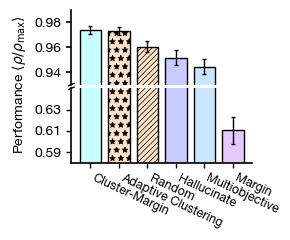

In [8]:
from matplotlib import gridspec
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.size'] = 10
plt.rcParams['hatch.linewidth'] = 0.5
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(3.0,2.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
b1 = ax1.bar(x_locations, levels, yerr=errors, width=0.75, color=colors, edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.0, 'capsize': 1.5, 'capthick': 1.0})
b2 = ax2.bar(x_locations, levels, yerr=errors, width=0.75, color=colors, edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.0, 'capsize': 1.5, 'capthick': 1.0})
b1[1].set_hatch('**')
b2[1].set_hatch('**')
b1[2].set_hatch('//////')
b2[2].set_hatch('//////')
ax1.set_ylim(0.93, 0.99)
ax2.set_ylim(0.58, 0.65)
ax1.spines[['bottom', 'top', 'right']].set_visible(False)
ax2.spines[['top', 'right']].set_visible(False)
d = 0.015  # size of diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.0)
ax1.plot((-d, +d), (-d, +d), **kwargs)      # left diagonal on ax1
# ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # right diagonal on ax1
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=1.0)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)   # left diagonal on ax2
# ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # right diagonal on ax2
ax1.set_ylabel(r'Performance $\langle\rho/\rho_{\text{max}}\rangle$', fontsize=10)
ax1.yaxis.set_label_coords(-0.24, 0.0)
ax1.set_xticks(ticks=[], labels=[])
ax2.set_xticks(ticks=[0, 1, 2, 3, 4, 5], labels=['Cluster-Margin', 'Adaptive Clustering', 'Random', 'Hallucinate', 'Multiobjective', 'Margin'], rotation=-25, fontsize=9, ha='left')
ax1.tick_params(axis='y', left=True, width=1.2, length=3.5)
ax1.tick_params(axis='x', bottom=False)
ax1.set_yticks(ticks=[0.98, 0.96, 0.94])
ax2.set_yticks(ticks=[0.59, 0.61, 0.63])
ax2.tick_params(axis='x', bottom=True, width=1.0, length=3.5)
ax2.tick_params(axis='y', left=True, width=1.0, length=3.5)
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig('./figures/graph_results.pdf', dpi=1000, transparent=True)
plt.show()

In [9]:
coverage_data = pd.read_csv(f'../graphs/metric.csv')

In [10]:
coverage_dict = {
    'Task': [],
    'Method': [],
    'Sampler': [],
    'Model': [],
    'Batch': [],
    'Seed': [],
    'Size': [],
    'coverage': []
}
for iter, row in coverage_data.iterrows():
    vals = row['path'][:-4].split('-')
    coverage_dict['Task'].append(vals[0])
    coverage_dict['Method'].append(vals[1])
    coverage_dict['Sampler'].append('none')
    coverage_dict['Model'].append('none')
    coverage_dict['Batch'].append('none')
    coverage_dict['Size'].append(int(vals[2]))
    coverage_dict['Seed'].append(int(vals[3]))
    coverage_dict['coverage'].append(row['coverage'])
coverage_df = pd.DataFrame(coverage_dict)
coverage_df.head(10)

,Task,Method,Sampler,Model,Batch,Seed,Size,coverage
0,freesolv,hallucinate,none,none,none,1,100,2.272761e+05
1,polygas_O2,random,none,none,none,8,100,8.383663e+05
2,polygas_H2,hallucinate,none,none,none,2,100,5.929224e+05
3,polygas_CH4,ensemble,none,none,none,7,100,5.986330e+05
4,polygas_N2,embedding,none,none,none,2,100,5.892461e+05
5,freesolv,penultimate,none,none,none,9,100,2.253974e+05
6,polygas_O2,penultimate,none,none,none,0,100,6.700920e+05
7,polygas_CO2,top,none,none,none,4,100,3.393195e+06
8,polygas_CH4,embedding,none,none,none,3,100,6.886202e+05
9,polygas_He,top,none,none,none,9,100,4.116017e+06


In [11]:
results = pd.read_csv('../graphs/results.csv')
results.head(10)

,Task,Method,Sampler,Model,Batch,Seed,Size,r2,mae,rmse,rmse-rel,pearson,spearman
0,freesolv,random,none,none,none,5,100,0.78264,0.30556,0.46622,0.46622,0.88517,0.87736
1,freesolv,random,none,none,none,7,100,0.70593,0.33244,0.54228,0.54228,0.84878,0.88753
2,polygas_He,random,none,none,none,6,100,0.70624,0.35177,0.54200,0.54200,0.85199,0.84653
3,polygas_CO2,random,none,none,none,1,100,0.76896,0.32278,0.48067,0.48067,0.87796,0.89374
4,polygas_H2,random,none,none,none,1,100,0.77995,0.29809,0.46910,0.46910,0.88492,0.89537
5,polygas_CO2,random,none,none,none,6,100,0.66622,0.37255,0.57774,0.57774,0.83035,0.83315
6,polygas_O2,random,none,none,none,7,100,0.63753,0.37380,0.60205,0.60205,0.80572,0.81097
7,sublimation,random,none,none,none,7,100,0.68427,0.37937,0.56190,0.56190,0.82922,0.84336
8,esol,random,none,none,none,7,100,0.80054,0.32280,0.44661,0.44661,0.89779,0.88527
9,esol,random,none,none,none,9,100,0.75375,0.35513,0.49624,0.49624,0.87717,0.87027


In [12]:
METRIC = 'spearman'
task_results = results[['Task', 'Method', 'Seed', 'Size', METRIC]]
task_results_long = task_results.melt(
    id_vars=['Task', 'Method', 'Seed'],
    value_vars=['spearman'],
    var_name='metric_full',
    value_name='metric_value'
)
task_results_long.head(10)
task_performances = task_results_long.loc[:,['Task', 'Method', 'Seed', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)
task_performances = task_performances[task_performances['mean'] > 0.1]
intermediate_tasks = task_performances['Task'].to_list()
print(f'Number of tasks: {len(intermediate_tasks)}')

Number of tasks: 30


In [13]:
# Compute aggregate rankings based on coverage.
average_results = coverage_df[coverage_df['Task'].isin(intermediate_tasks)]
norm_factors = average_results.groupby(['Task', 'Method', 'Sampler', 'Model', 'Batch'])['coverage'].mean().reset_index()
norm_factors = norm_factors.groupby('Task')['coverage'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['coverage'].to_dict()
average_results['coverage_norm'] = average_results.loc[:,'coverage'] / average_results['Task'].map(norm_factors)
average_results = average_results[['Method', 'Sampler', 'Model', 'Batch', 'coverage_norm']]
average_results_grouped = average_results.groupby(['Method', 'Sampler', 'Model', 'Batch'])
average_results_agg = average_results_grouped['coverage_norm'].agg(['mean', 'sem']).reset_index()
coverage_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
coverage_results_agg.columns = ['Method', 'Sampler', 'Model', 'Batch', 'coverage-mean', 'coverage-sem']
coverage_results_agg = coverage_results_agg[['Method', 'coverage-mean', 'coverage-sem']]
coverage_results_agg.head(10)

,Method,coverage-mean,coverage-sem
6,top,10.088486,0.363412
3,pareto,2.180613,0.046093
5,random,1.190910,0.013602
2,hallucinate,1.133615,0.028097
4,penultimate,1.113830,0.012099
0,embedding,1.090530,0.012081
1,ensemble,1.000321,0.010920


In [14]:
METRIC = 'spearman'
intermediate_results = results[['Task', 'Method', 'Seed', 'Size', METRIC]]
intermediate_results_long = intermediate_results.melt(
    id_vars=['Task', 'Method', 'Seed'],
    value_vars=[METRIC],
    var_name='metric_full',
    value_name='metric_value'
)
intermediate_results_long.head(10)
intermediate_results_long = intermediate_results_long[intermediate_results_long['Task'].isin(intermediate_tasks)]

norm_factors = intermediate_results_long.groupby(['Task', 'Method'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
intermediate_results_long['score_norm'] = intermediate_results_long['metric_value'] / intermediate_results_long['Task'].map(norm_factors)
intermediate_results_long = intermediate_results_long[['Method', 'score_norm']]

intermediate_results_grouped = intermediate_results_long.groupby(['Method'])
intermediate_results_agg = intermediate_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    intermediate_results_agg = intermediate_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rmse-rel']:
    intermediate_results_agg = intermediate_results_agg.sort_values(by='mean', ascending=True)

intermediate_results_agg.columns = ['Method', 'metric-mean', 'metric-sem']
intermediate_results_agg.head(50)

,Method,metric-mean,metric-sem
1,ensemble,0.973858,0.003154
0,embedding,0.973449,0.003213
4,penultimate,0.969501,0.003366
5,random,0.960566,0.004506
2,hallucinate,0.951684,0.005882
3,pareto,0.944503,0.006046
6,top,0.610605,0.012555


In [15]:
# Merge tables of metrics.
merged = coverage_results_agg.merge(
    intermediate_results_agg,
    on=['Method']
)
merged.head(10)

,Method,coverage-mean,coverage-sem,metric-mean,metric-sem
0,top,10.088486,0.363412,0.610605,0.012555
1,pareto,2.180613,0.046093,0.944503,0.006046
2,random,1.190910,0.013602,0.960566,0.004506
3,hallucinate,1.133615,0.028097,0.951684,0.005882
4,penultimate,1.113830,0.012099,0.969501,0.003366
5,embedding,1.090530,0.012081,0.973449,0.003213
6,ensemble,1.000321,0.010920,0.973858,0.003154


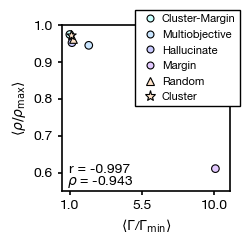

In [16]:
# Remove penultimate data.
merged_simple = merged[merged['Method'] != 'penultimate']

# Visualize correlation between coverage and performance.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.2
fig, ax = plt.subplots(1,1,figsize=(2.5, 2.5))

colors = []
random_idx = -1
cluster_idx = -1
al_idx = []
for iter, (_, row) in enumerate(merged_simple.iterrows()):
    if row['Method'] == 'ensemble':
        colors.append("#C9FFFE")
        al_idx.append(iter)
    elif row['Method'] == 'hallucinate':
        colors.append("#C9CAFF")
        al_idx.append(iter)
    elif row['Method'] == 'top':
        colors.append("#E3C9FF")
        al_idx.append(iter)
    elif row['Method'] == 'pareto':
        colors.append('#C9E5FF')
        al_idx.append(iter)
    elif row['Method'] == 'random':
        random_idx = iter
    else:
        cluster_idx = iter

ax.scatter(merged_simple.iloc[al_idx]['coverage-mean'], merged_simple.iloc[al_idx]['metric-mean'], s=30, color=colors, edgecolors='black', linewidth=0.8)
ax.scatter(merged_simple.iloc[random_idx]['coverage-mean'], merged_simple.iloc[random_idx]['metric-mean'], s=30, marker='^', color='#FFE3C9', edgecolors='black', linewidth=0.8)
ax.scatter(merged_simple.iloc[cluster_idx]['coverage-mean'], merged_simple.iloc[cluster_idx]['metric-mean'], s=50, marker='*', color='#FFE3C9', edgecolors='black', linewidth=0.8)
ax.set_xlabel(r'$\langle\Gamma$/$\Gamma_{\text{min}}\rangle$')
ax.set_xlim(xmin=0.5, xmax=11)
ax.set_xticks(ticks=[1.0, 5.5, 10.0])
ax.set_ylim(ymin=0.55, ymax=1.00)
ax.set_ylabel(r'$\langle\rho/\rho_{\text{max}}\rangle$')
ax.tick_params(axis='both', left=True, bottom=True, width=1.2, length=3.0)

from scipy.stats import pearsonr, spearmanr
r = pearsonr(merged_simple['coverage-mean'], merged_simple['metric-mean']).statistic
rho = spearmanr(merged_simple['coverage-mean'], merged_simple['metric-mean']).statistic
ax.text(0.04, 0.11, f'r = {r:.3f}', ha='left', transform=ax.transAxes)
ax.text(0.03, 0.035, rf'$\rho$ = {rho:.3f}', ha='left', transform=ax.transAxes)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Cluster-Margin',
        markerfacecolor='#C9FFFE',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Multiobjective',
        markerfacecolor='#C9E5FF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Hallucinate',
        markerfacecolor='#C9CAFF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label='Margin',
        markerfacecolor='#E3C9FF',
        markeredgecolor='black',
        markersize=5,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='^',
        color='none',
        label='Random',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=6,
        mew=0.8
    ),
    Line2D(
        [0], [0],
        marker='*',
        color='none',
        label='Cluster',
        markerfacecolor='#FFE3C9',
        markeredgecolor='black',
        markersize=8,
        mew=0.8
    ),
]

leg = ax.legend(
    handles=legend_elements, edgecolor='black', handletextpad=0.05, fontsize=8, fancybox=False,
    bbox_to_anchor=(0.4, 0.8), loc='center left', framealpha=1
)

plt.tight_layout()
plt.savefig('./figures/wcss_graph.pdf', dpi=500, transparent=True)
plt.show()